In [ ]:
import random
import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

#  Set a fixed seed value so that all random operations are reproducible
SEED = 42

# Seed Python's built-in random module
random.seed(SEED)

# Seed NumPy's random number generator
np.random.seed(SEED)

# Seed PyTorch's CPU random number generator
torch.manual_seed(SEED)

# If a CUDA GPU is available, also seed all CUDA random number generators
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("GPU Is available")

# Print the installed PyTorch version for reference
print("Using torch version:", torch.__version__)



GPU Is available
Using torch version: 2.8.0+cu126


In [ ]:
#Load CIFAR-10 and show class names

# Use the same simple transform just convert PIL image-tensor
transform = T.ToTensor()

# Load CIFAR-10 training set
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# List of class names, in order 0-9
class_names = train_dataset.classes

print("CIFAR-10 classes (index : name):")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

100%|██████████| 170M/170M [00:04<00:00, 35.3MB/s]


CIFAR-10 classes (index : name):
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


In [ ]:
# Choose any two classes by their index
CLASS_A = 2   # bird
CLASS_B = 8   # ship

print("Chosen classes for two-class classification:")
print(f"CLASS_A = {CLASS_A} -> {class_names[CLASS_A]}")
print(f"CLASS_B = {CLASS_B} -> {class_names[CLASS_B]}")

# indices in the training set that belong to these two classes
train_idx_A = []
train_idx_B = []

for idx, (_, label) in enumerate(train_dataset):
    if label == CLASS_A:
        train_idx_A.append(idx)
    elif label == CLASS_B:
        train_idx_B.append(idx)

print(f"Total {class_names[CLASS_A]} images in full training set:", len(train_idx_A))
print(f"Total {class_names[CLASS_B]} images in full training set:", len(train_idx_B))

Chosen classes for two-class classification:
CLASS_A = 2 -> bird
CLASS_B = 8 -> ship
Total bird images in full training set: 5000
Total ship images in full training set: 5000


In [ ]:
# SEED for reproducibility
rng = np.random.RandomState(42)

# Shuffle the index lists IN-PLACE
rng.shuffle(train_idx_A)
rng.shuffle(train_idx_B)

# first 2000 indices from each shuffled list
train_idx_A_2000 = train_idx_A[:2000]
train_idx_B_2000 = train_idx_B[:2000]

print(f"Selected {len(train_idx_A_2000)} {class_names[CLASS_A]} images for TRAINING")
print(f"Selected {len(train_idx_B_2000)} {class_names[CLASS_B]} images for TRAINING")

# Combine them into one list of training indices
train_indices_two_class = train_idx_A_2000 + train_idx_B_2000

print("Total two-class training samples:", len(train_indices_two_class))

Selected 2000 bird images for TRAINING
Selected 2000 ship images for TRAINING
Total two-class training samples: 4000


In [ ]:
#Center-crop to 10×10×3 and flatten to 300-D

def center_crop_10x10(img_tensor: torch.Tensor) -> torch.Tensor:

    # img_tensor has shape [channels, height, width] = [3, 32, 32]
    _, H, W = img_tensor.shape  #  3, 32, 32

    # We want a 10x10 crop
    crop_size = 10

    # Compute where to start the crop (top-left corner) so it is centered
    # For CIFAR-10: (32 - 10) // 2 = 11, so we take rows/cols 11..20
    start_h = (H - crop_size) // 2  # (32 - 10) // 2 = 11
    start_w = (W - crop_size) // 2

    # Slice out a [3, 10, 10] patch from the center
    cropped = img_tensor[:, start_h:start_h+crop_size,
                             start_w:start_w+crop_size]

   # Return the cropped image (still a 3-channel tensor, but now 10x10)
    return cropped  # shape [3, 10, 10]



def img_to_feature_300(img_tensor: torch.Tensor) -> np.ndarray:

  # First, center-crop from [3, 32, 32] to [3, 10, 10]
    cropped = center_crop_10x10(img_tensor)  # [3, 10, 10]

    # Flatten all pixels into a single vector of length 300
    # Use .reshape(-1) to handle non-contiguous tensors
    feat = cropped.reshape(-1) # shape [300]

    # Convert from torch tensor to NumPy array, type float32
    return feat.numpy().astype(np.float32)   # return as NumPy array

In [ ]:
#Build X_train and y_train using the selected indices

def build_xy_from_indices(dataset, idx_A_list, idx_B_list):

  X_list = []  # will store 300-D feature vectors
  y_list = []  # will store class labels (0 or 1)

  # Process CLASS_A images
  for idx in idx_A_list:
        # Get the image and label from the dataset
        img, _ = dataset[idx]    # img shape: [3, 32, 32]

        # Convert image to a 300-D feature vector
        feat = img_to_feature_300(img)  # shape: [300]

        # Add feature and label to our lists
        X_list.append(feat)
        y_list.append(0)

  # Process CLASS_B images
  for idx in idx_B_list:
        img, _ = dataset[idx]
        feat = img_to_feature_300(img) # shape: [300]

        X_list.append(feat)
        y_list.append(1) # CLASS_B -> label 1

  # Stack list of feature vectors into one 2D array: [N, 300]
  X = np.stack(X_list, axis=0)

  # Convert list of labels into a 1D array: [N]
  y = np.array(y_list, dtype=np.int64)

  return X, y

# Use the function to create training data

X_train, y_train = build_xy_from_indices(
    train_dataset,
    train_idx_A_2000,   # 2000 indices for CLASS_A
    train_idx_B_2000    # 2000 indices for CLASS_B
)

print("X_train shape:", X_train.shape)   # (4000, 300)
print("y_train shape:", y_train.shape)   # (4000,)
print("First 10 labels in y_train:", y_train[:10])
print("Count of class 0:", np.sum(y_train == 0))
print("Count of class 1:", np.sum(y_train == 1))

X_train shape: (4000, 300)
y_train shape: (4000,)
First 10 labels in y_train: [0 0 0 0 0 0 0 0 0 0]
Count of class 0: 2000
Count of class 1: 2000


In [ ]:
#Load CIFAR-10 test set and pick 100 images per class

# Load the CIFAR-10 TEST dataset (10,000 images)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=T.ToTensor()
)

print("Loaded test dataset with length:", len(test_dataset))

# indices for the two chosen classes in the TEST set
test_idx_A = []
test_idx_B = []

for idx, (_, label) in enumerate(test_dataset):
    if label == CLASS_A:
        test_idx_A.append(idx)
    elif label == CLASS_B:
        test_idx_B.append(idx)

print(f"Total {class_names[CLASS_A]} images in TEST set:", len(test_idx_A))
print(f"Total {class_names[CLASS_B]} images in TEST set:", len(test_idx_B))

# random seed to pick 100 images from each class reproducibly
rng = np.random.RandomState(42)

rng.shuffle(test_idx_A)
rng.shuffle(test_idx_B)

test_idx_A_100 = test_idx_A[:100]   # first 100 shuffled indices for bird
test_idx_B_100 = test_idx_B[:100]   # first 100 shuffled indices for ship

print(f"Selected {len(test_idx_A_100)} {class_names[CLASS_A]} images for TEST")
print(f"Selected {len(test_idx_B_100)} {class_names[CLASS_B]} images for TEST")


test_indices_two_class = test_idx_A_100 + test_idx_B_100
print("Total two-class TEST samples:", len(test_indices_two_class))

Loaded test dataset with length: 10000
Total bird images in TEST set: 1000
Total ship images in TEST set: 1000
Selected 100 bird images for TEST
Selected 100 ship images for TEST
Total two-class TEST samples: 200


In [ ]:
# X_test and y_test (cropped to 10×10×3 → 300-D)

X_test, y_test = build_xy_from_indices(
    test_dataset,
    test_idx_A_100,
    test_idx_B_100
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Count of class 0 in y_test:", np.sum(y_test == 0))
print("Count of class 1 in y_test:", np.sum(y_test == 1))
print("First 10 labels in y_test:", y_test[:10])
print("Last 10 labels in y_test:", y_test[-10:])


X_test shape: (200, 300)
y_test shape: (200,)
Count of class 0 in y_test: 100
Count of class 1 in y_test: 100
First 10 labels in y_test: [0 0 0 0 0 0 0 0 0 0]
Last 10 labels in y_test: [1 1 1 1 1 1 1 1 1 1]


In [ ]:
# Gaussian Naive Bayes algorithm

import numpy as np

def gaussian_naive_bayes_algo(X_train, y_train, eps: float = 1e-6):

    # Number of training examples N and number of features D.
    N, D = X_train.shape

    # Unique class labels, should be [0, 1]
    classes = np.unique(y_train)

    # Dictionaries to store parameters for each class
    priors = {}  # P(class)
    means  = {}  # μ_{class, j}
    stds   = {}  # σ_{class, j}

    # Loop over each class separately
    for c in classes:
        # Select all rows belonging to class c
        X_c = X_train[y_train == c]
        N_c = X_c.shape[0]  # number of samples in this class

        # Prior probability P(class = c) = N_c / N
        priors[c] = N_c / N

        # Mean of each feature j for this class: μ_{c,j}
        means[c] = X_c.mean(axis=0)   # shape [D]

        # Standard deviation of each feature j for this class: σ_{c,j}
        # ddof=0 -> population standard deviation
        std_c = X_c.std(axis=0, ddof=0)  # shape [D]

        # Avoid zero standard deviation, which would cause division by zero
        std_c = np.where(std_c < eps, eps, std_c)

        stds[c] = std_c

    return priors, means, stds


# Apply (fit) Gaussian Naive Bayes on the 4000 training images
priors, means, stds = gaussian_naive_bayes_algo(X_train, y_train)

print("Class priors:", priors)
print("Means[0] shape:", means[0].shape)
print("Stds[0] shape:", stds[0].shape)
print("Means[1] shape:", means[1].shape)
print("Stds[1] shape:", stds[1].shape)


Class priors: {np.int64(0): 0.5, np.int64(1): 0.5}
Means[0] shape: (300,)
Stds[0] shape: (300,)
Means[1] shape: (300,)
Stds[1] shape: (300,)


In [ ]:
# Predict on test data + accuracy

def gaussian(x, mu, sigma):
    coeff = 1.0 / (np.sqrt(2.0 * np.pi) * sigma) # 1/(sqrt(2π)*σ)
    exponent = np.exp(-0.5 * ((x - mu) ** 2) / (sigma ** 2))# exp(-(x-μ)^2/(2σ^2))
    return coeff * exponent

def predict_gaussian_nb(X, priors, means, stds):
    N, D = X.shape
    classes = sorted(priors.keys())

    # store log posterior scores for each class, shape -> [num_classes, N]
    log_posteriors = []

    for c in classes:
        mu_c = means[c] # shape (D,)
        sd_c = stds[c]  # shape (D,)

        # Compute Gaussian for all samples and all features
        # X shape: (N, D), mu_c and sd_c broadcast to (N, D)
        vals = gaussian(X, mu_c, sd_c)   # shape (N, D)

        # To avoid underflow, work in log space:
        log_vals = np.log(vals + 1e-30)  # add tiny constant to avoid log(0)
        log_likelihood = log_vals.sum(axis=1) # shape (N,)

        # Add log prior: log P(class=c)
        log_prior = np.log(priors[c]) # scalar

        log_post = log_prior + log_likelihood
        log_posteriors.append(log_post)

    # Stack into array of shape [num_classes, N]
    log_posteriors = np.vstack(log_posteriors)

    # For each example, pick the class with the larger log posterior
    y_pred = np.argmax(log_posteriors, axis=0)  # shape (N,)

    return y_pred


# predict on the 200 test images
y_pred = predict_gaussian_nb(X_test, priors, means, stds)

# Compute classification accuracy
accuracy = (y_pred == y_test).mean()
print(f"Test accuracy on 200 test images: {accuracy:.4f}")

Test accuracy on 200 test images: 0.7550


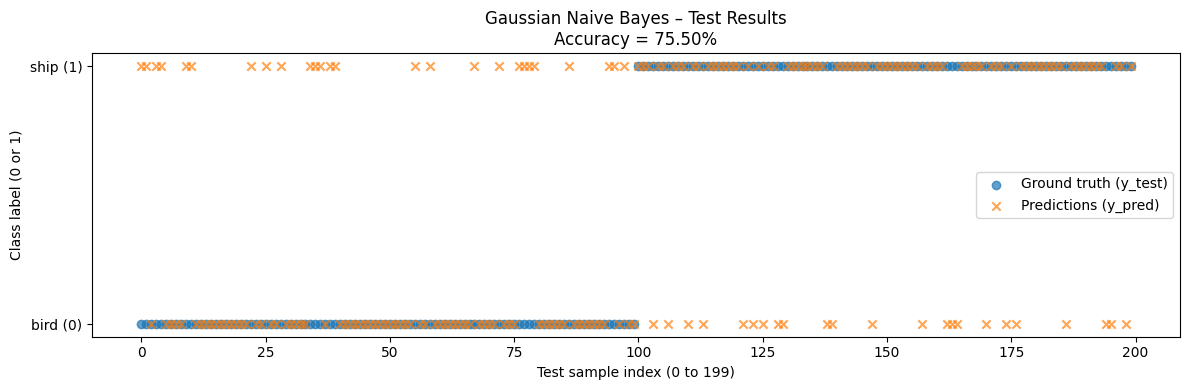

Test accuracy on 200 test images: 0.7550  (75.50%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.arange(len(y_test))

plt.figure(figsize=(12, 4))

# Ground truth labels (0 or 1)
plt.scatter(
    indices,
    y_test,
    marker='o',
    alpha=0.7,
    label='Ground truth (y_test)'
)

# Predicted labels (0 or 1)
plt.scatter(
    indices,
    y_pred,
    marker='x',
    alpha=0.7,
    label='Predictions (y_pred)'
)

plt.yticks(
    [0, 1],
    [f"{class_names[CLASS_A]} (0)", f"{class_names[CLASS_B]} (1)"]
)

plt.xlabel("Test sample index (0 to 199)")
plt.ylabel("Class label (0 or 1)")
plt.title(f"Gaussian Naive Bayes – Test Results\nAccuracy = {accuracy*100:.2f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Test accuracy on 200 test images: {accuracy:.4f}  ({accuracy*100:.2f}%)")
